<a href="https://colab.research.google.com/github/DilshanBotheju/CSACP_Project/blob/main/HomicidePatternRecognizerClusteringModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [253]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [254]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [255]:
#Load relevant datasets
homicide_data_path = "/content/drive/MyDrive/DSGP/datasets/preprocessed_dataset.csv"
homicide_data = pd.read_csv(homicide_data_path, encoding = "latin-1")
homicide_data.head(10)

,City,State,Year,Month,Incident,Crime Type,Victim Sex,Victim Age,Victim Race,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Perpetrator Age Group
0,San Bernardino,California,2005,7,1,Murder or Manslaughter,Male,18,White,Male,0.0,White,Acquaintance,Handgun,1,0,Teen (13-19),NaN
1,Harris,Texas,2013,5,3,Murder or Manslaughter,Male,27,White,Male,0.0,White,Acquaintance,Firearm,0,0,Young Adult (20-29),NaN
2,St. Francis,Arkansas,2001,6,1,Murder or Manslaughter,Male,42,Black,Male,18.0,Black,Acquaintance,Handgun,0,0,Adult (30-49),Teen (13-19)
3,Pima,Arizona,1998,3,6,Murder or Manslaughter,Male,44,White,Male,0.0,White,Acquaintance,Handgun,0,0,Adult (30-49),NaN
4,Okanogan,Washington,1999,8,1,Murder or Manslaughter,Female,15,White,Male,20.0,White,Girlfriend,Rifle,0,0,Teen (13-19),Young Adult (20-29)
5,Kalkaska,Michigan,2008,8,1,Murder or Manslaughter,Male,3,White,Male,25.0,White,Acquaintance,Blunt Object,0,2,Child (0-12),Young Adult (20-29)
6,Spokane,Washington,2001,3,1,Murder or Manslaughter,Male,37,White,Male,0.0,White,Acquaintance,Handgun,0,0,Adult (30-49),NaN
7,Baltimore city,Maryland,2005,1,13,Murder or Manslaughter,Male,22,Black,Male,0.0,White,Acquaintance,Handgun,0,0,Young Adult (20-29),NaN
8,Lafayette,Louisiana,2014,2,1,Murder or Manslaughter,Male,49,White,Male,15.0,Black,Husband,Firearm,0,0,Adult (30-49),Teen (13-19)
9,Gaston,North Carolina,2009,4,1,Murder or Manslaughter,Female,17,Black,Male,21.0,Black,Stranger,Handgun,0,1,Teen (13-19),Young Adult (20-29)


In [256]:
homicide_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638454 entries, 0 to 638453
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   City                   638454 non-null  object 
 1   State                  638454 non-null  object 
 2   Year                   638454 non-null  int64  
 3   Month                  638454 non-null  int64  
 4   Incident               638454 non-null  int64  
 5   Crime Type             638454 non-null  object 
 6   Victim Sex             638454 non-null  object 
 7   Victim Age             638454 non-null  int64  
 8   Victim Race            638454 non-null  object 
 9   Perpetrator Sex        638454 non-null  object 
 10  Perpetrator Age        638453 non-null  float64
 11  Perpetrator Race       638454 non-null  object 
 12  Relationship           638454 non-null  object 
 13  Weapon                 638454 non-null  object 
 14  Victim Count           638454 non-nu

EDA (Exploratory Data Analysis)

<ipython-input-257-372c2f28047c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=homicide_data, y="Crime Type", order=homicide_data["Crime Type"].value_counts().index, palette="coolwarm")


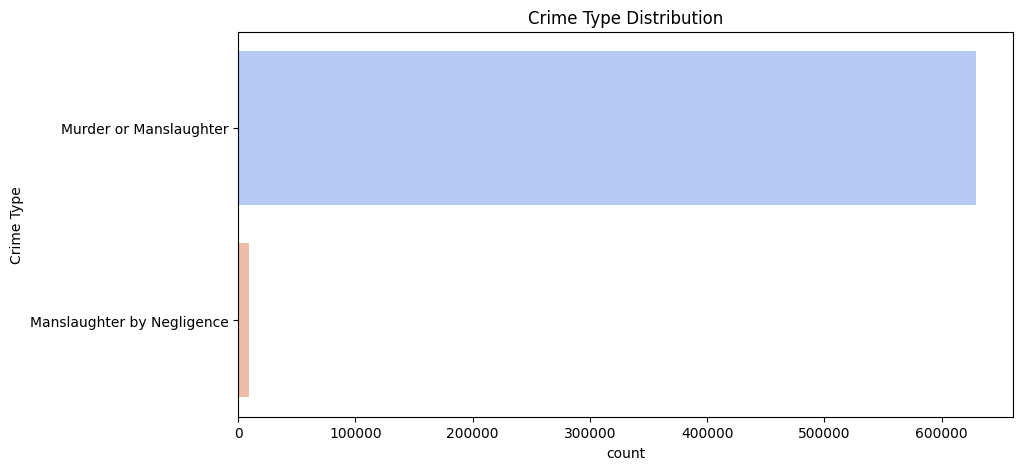

In [257]:
# Distribution of homicide crime types
plt.figure(figsize=(10,5))
sns.countplot(data=homicide_data, y="Crime Type", order=homicide_data["Crime Type"].value_counts().index, palette="coolwarm")
plt.title("Crime Type Distribution")
plt.show()

<ipython-input-258-b69b9ed5197d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=homicide_data, y="Weapon", order=homicide_data["Weapon"].value_counts().head(10).index, palette="magma")


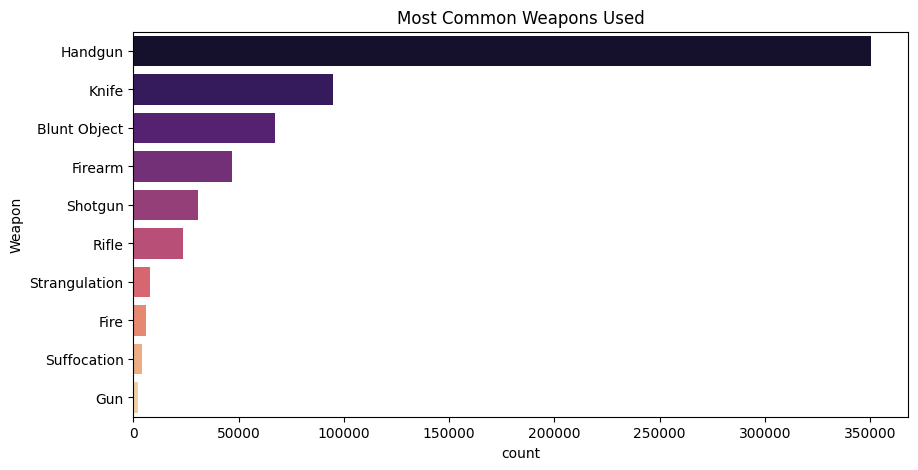

In [258]:
# Plotting most common weapons used
plt.figure(figsize=(10,5))
sns.countplot(data=homicide_data, y="Weapon", order=homicide_data["Weapon"].value_counts().head(10).index, palette="magma")
plt.title("Most Common Weapons Used")
plt.show()

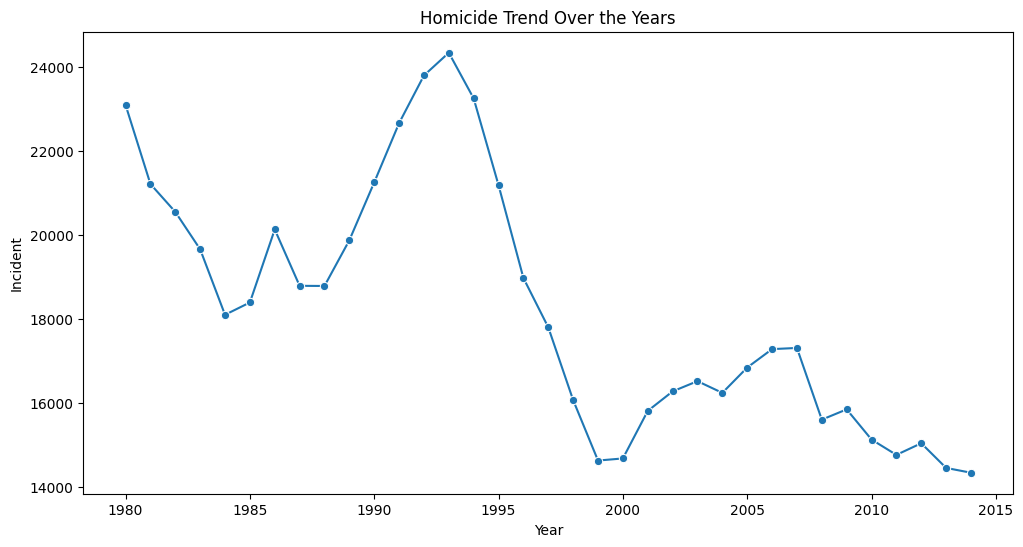

In [259]:
# Identify homicide trends over time
plt.figure(figsize=(12, 6))
sns.lineplot(x="Year", y="Incident", data=homicide_data.groupby("Year")["Incident"].count().reset_index(), marker="o")
plt.title("Homicide Trend Over the Years")
plt.show()

In [260]:
# Drop unnecessary columns
homicide_data = homicide_data.drop(columns=["Perpetrator Age","Victim Age","Incident","Crime Type","Victim Race","Perpetrator Race","Perpetrator Count"])

In [261]:
# View data
homicide_data.head()

,City,State,Year,Month,Victim Sex,Perpetrator Sex,Relationship,Weapon,Victim Count,Victim Age Group,Perpetrator Age Group
0,San Bernardino,California,2005,7,Male,Male,Acquaintance,Handgun,1,Teen (13-19),NaN
1,Harris,Texas,2013,5,Male,Male,Acquaintance,Firearm,0,Young Adult (20-29),NaN
2,St. Francis,Arkansas,2001,6,Male,Male,Acquaintance,Handgun,0,Adult (30-49),Teen (13-19)
3,Pima,Arizona,1998,3,Male,Male,Acquaintance,Handgun,0,Adult (30-49),NaN
4,Okanogan,Washington,1999,8,Female,Male,Girlfriend,Rifle,0,Teen (13-19),Young Adult (20-29)


In [262]:
# Check null values
homicide_data.isnull().sum()

,0
City,0
State,0
Year,0
Month,0
Victim Sex,0
Perpetrator Sex,0
Relationship,0
Weapon,0
Victim Count,0
Victim Age Group,9418


In [263]:
# Drop unnecessary columns
homicide_data = homicide_data.drop(columns=["Perpetrator Age Group"])

In [264]:
# Getting a sample percentage of data to preprocess
data_percentage = 0.5
homicide_data = homicide_data.sample(frac=data_percentage, random_state=42)

In [265]:
# Replacing NA with Unknown to identify null columns
homicide_data.replace( np.nan,"Unknown", inplace=True)

In [266]:
# View data
homicide_data.head()

,City,State,Year,Month,Victim Sex,Perpetrator Sex,Relationship,Weapon,Victim Count,Victim Age Group
484984,Baltimore city,Maryland,1996,8,Male,Male,Acquaintance,Handgun,0,Senior (50+)
608445,Essex,New Jersey,2013,9,Male,Male,Stranger,Handgun,0,Young Adult (20-29)
417612,Wayne,Michigan,1997,11,Male,Male,Acquaintance,Firearm,0,Young Adult (20-29)
372692,Dade,Florida,1995,12,Male,Male,Son,Blunt Object,0,Child (0-12)
402028,Los Angeles,California,2002,11,Male,Male,Stranger,Handgun,0,Teen (13-19)


In [267]:
# View dataset info
homicide_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 319227 entries, 484984 to 190407
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   City              319227 non-null  object
 1   State             319227 non-null  object
 2   Year              319227 non-null  int64 
 3   Month             319227 non-null  int64 
 4   Victim Sex        319227 non-null  object
 5   Perpetrator Sex   319227 non-null  object
 6   Relationship      319227 non-null  object
 7   Weapon            319227 non-null  object
 8   Victim Count      319227 non-null  int64 
 9   Victim Age Group  319227 non-null  object
dtypes: int64(3), object(7)
memory usage: 26.8+ MB


In [268]:
# Get value count for city
homicide_data["City"].value_counts()

,count
City,
Los Angeles,22137
New York,19174
Cook,11086
Wayne,9902
Harris,8179
...,...
Wheatland,1
Prince of Wales-Outer Ketchikan,1
Loup,1


In [269]:
# Get value count for state
homicide_data["State"].value_counts()

,count
State,
California,49939
Texas,31010
New York,24526
Florida,18463
Michigan,14178
Illinois,12818
Pennsylvania,12285
Georgia,10642
North Carolina,10240


In [270]:
# Drop state and city due to high categorical count
homicide_data = homicide_data.drop(columns=["City"])

In [271]:
# Viewing the data
homicide_data.head()

,State,Year,Month,Victim Sex,Perpetrator Sex,Relationship,Weapon,Victim Count,Victim Age Group
484984,Maryland,1996,8,Male,Male,Acquaintance,Handgun,0,Senior (50+)
608445,New Jersey,2013,9,Male,Male,Stranger,Handgun,0,Young Adult (20-29)
417612,Michigan,1997,11,Male,Male,Acquaintance,Firearm,0,Young Adult (20-29)
372692,Florida,1995,12,Male,Male,Son,Blunt Object,0,Child (0-12)
402028,California,2002,11,Male,Male,Stranger,Handgun,0,Teen (13-19)


In [272]:
# Get weapon value count
homicide_data["Weapon"].value_counts()

,count
Weapon,
Handgun,175252
Knife,47515
Blunt Object,33759
Firearm,23587
Shotgun,15290
Rifle,11676
Strangulation,4004
Fire,3096
Suffocation,1981


Feature Engineering

In [273]:
# Convert Year and Month into datetime
homicide_data["Date"] = pd.to_datetime(homicide_data["Year"].astype(str) + "-" + homicide_data["Month"].astype(str) + "-01")
homicide_data = homicide_data.sort_values(by="Date")

In [274]:
homicide_data.head(30)

,State,Year,Month,Victim Sex,Perpetrator Sex,Relationship,Weapon,Victim Count,Victim Age Group,Date
542676,Louisiana,1980,1,Female,Male,Wife,Handgun,0,Young Adult (20-29),1980-01-01
228647,New Jersey,1980,1,Male,Male,Acquaintance,Handgun,0,Young Adult (20-29),1980-01-01
433547,Illinois,1980,1,Male,Male,In-Law,Handgun,0,Adult (30-49),1980-01-01
411294,Michigan,1980,1,Male,Female,Boyfriend,Rifle,0,Young Adult (20-29),1980-01-01
35176,Indiana,1980,1,Male,Male,Acquaintance,Handgun,0,Adult (30-49),1980-01-01
1887,Colorado,1980,1,Male,Male,Stranger,Handgun,0,Adult (30-49),1980-01-01
170964,Illinois,1980,1,Male,Male,Acquaintance,Handgun,0,Young Adult (20-29),1980-01-01
278679,Virginia,1980,1,Male,Male,Acquaintance,Blunt Object,0,Adult (30-49),1980-01-01
617282,New York,1980,1,Male,Male,Acquaintance,Handgun,0,Child (0-12),1980-01-01
540039,California,1980,1,Male,Male,Acquaintance,Knife,0,Young Adult (20-29),1980-01-01


In [275]:
# Compute time difference between crimes in the same city
homicide_data["Time_Diff"] = homicide_data.groupby("State")["Date"].diff().dt.days.fillna(0)

# Crime frequency per city
crime_counts = homicide_data.groupby("State").size().reset_index(name="Crime_Frequency")
homicide_data = homicide_data.merge(crime_counts, on="State")

In [276]:
def categorize_crime(count):
    if count >= 10000:
        return "High Crime"
    elif 5000 <= count < 10000:
        return "Medium-High Crime"
    elif 1000 <= count < 5000:
        return "Medium-Low Crime"
    else:
        return "Low Crime"

# Apply categorization function
homicide_data["State_Crime_Category"] = homicide_data["Crime_Frequency"].apply(categorize_crime)



In [277]:
homicide_data.head()

,State,Year,Month,Victim Sex,Perpetrator Sex,Relationship,Weapon,Victim Count,Victim Age Group,Date,Time_Diff,Crime_Frequency,State_Crime_Category
0,Louisiana,1980,1,Female,Male,Wife,Handgun,0,Young Adult (20-29),1980-01-01,0.0,9768,Medium-High Crime
1,New Jersey,1980,1,Male,Male,Acquaintance,Handgun,0,Young Adult (20-29),1980-01-01,0.0,7086,Medium-High Crime
2,Illinois,1980,1,Male,Male,In-Law,Handgun,0,Adult (30-49),1980-01-01,0.0,12818,High Crime
3,Michigan,1980,1,Male,Female,Boyfriend,Rifle,0,Young Adult (20-29),1980-01-01,0.0,14178,High Crime
4,Indiana,1980,1,Male,Male,Acquaintance,Handgun,0,Adult (30-49),1980-01-01,0.0,5711,Medium-High Crime


In [278]:
# Relationship value count
homicide_data["Relationship"].value_counts()

,count
Relationship,
Acquaintance,199527
Stranger,48349
Wife,11524
Friend,10975
Girlfriend,8181
Son,5019
Family,4768
Husband,4405
Daughter,3904


In [279]:
def categorize_relationship(relationship):

    if relationship in ['Wife', 'Husband', 'Father', 'Mother', 'Son', 'Daughter', 'Brother', 'Sister',
                        'In-Law', 'Common-Law Wife', 'Common-Law Husband']:
        return 'Family'
    elif relationship in ['Stepmother', 'Stepfather', 'Stepson', 'Stepdaughter', 'Ex-Wife', 'Ex-Husband']:
        return 'Stepfamily'
    elif relationship in ['Boyfriend', 'Girlfriend', 'Boyfriend/Girlfriend']:
        return 'Partner/Spouse'
    elif relationship in ['Friend', 'Neighbor', 'Acquaintance']:
        return 'Friend/Acquaintance'
    elif relationship in ['Employer', 'Employee']:
        return 'Work/Employer'
    elif relationship == 'Stranger':
        return 'Stranger'
    else:
        return 'Other'

# Apply method
homicide_data["Relationship"] = homicide_data["Relationship"].apply(categorize_relationship)

In [280]:
# Check value count for weapons
homicide_data["Weapon"].value_counts()

,count
Weapon,
Handgun,175252
Knife,47515
Blunt Object,33759
Firearm,23587
Shotgun,15290
Rifle,11676
Strangulation,4004
Fire,3096
Suffocation,1981


In [281]:
def categorize_weapon(weapon):
    if weapon in ['Handgun', 'Firearm', 'Shotgun', 'Rifle', 'Gun']:
        return 'Firearms'
    elif weapon == 'Blunt Object':
        return 'Blunt Objects'
    elif weapon in ['Strangulation', 'Suffocation']:
        return 'Strangulation/Suffocation'
    elif weapon in ['Poison', 'Drugs']:
        return 'Poisoning'
    elif weapon in ['Fire', 'Drowning', 'Explosives', 'Fall']:
        return 'Environmental/Accidental'
    else:
        return 'Other'

# Apply method
homicide_data["Weapon"] = homicide_data["Weapon"].apply(categorize_weapon)

In [282]:
# Drop columns
homicide_data = homicide_data.drop(columns=["Year","State","Month"])

In [283]:
homicide_data.head()

,Victim Sex,Perpetrator Sex,Relationship,Weapon,Victim Count,Victim Age Group,Date,Time_Diff,Crime_Frequency,State_Crime_Category
0,Female,Male,Family,Firearms,0,Young Adult (20-29),1980-01-01,0.0,9768,Medium-High Crime
1,Male,Male,Friend/Acquaintance,Firearms,0,Young Adult (20-29),1980-01-01,0.0,7086,Medium-High Crime
2,Male,Male,Family,Firearms,0,Adult (30-49),1980-01-01,0.0,12818,High Crime
3,Male,Female,Partner/Spouse,Firearms,0,Young Adult (20-29),1980-01-01,0.0,14178,High Crime
4,Male,Male,Friend/Acquaintance,Firearms,0,Adult (30-49),1980-01-01,0.0,5711,Medium-High Crime


In [284]:
from sklearn.preprocessing import OneHotEncoder

# One hot encode categorical features
homicide_data = pd.get_dummies(homicide_data, columns=["Victim Sex", "Perpetrator Sex", "Relationship", "Weapon"], drop_first=False)

In [285]:
# Label encode ordinal features
label_encoder = LabelEncoder()
homicide_data["Victim Age Group"] = label_encoder.fit_transform(homicide_data["Victim Age Group"])
print("Mapping of categories to labels:")
for original, encoded in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{original}: {encoded}")

Mapping of categories to labels:
Adult (30-49): 0
Child (0-12): 1
Senior (50+): 2
Teen (13-19): 3
Unknown: 4
Young Adult (20-29): 5


In [286]:
# label encode state crime category
label_encoder = LabelEncoder()
homicide_data["State_Crime_Category"] = label_encoder.fit_transform(homicide_data["State_Crime_Category"])
print("Mapping of categories to labels:")
for original, encoded in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{original}: {encoded}")


Mapping of categories to labels:
High Crime: 0
Low Crime: 1
Medium-High Crime: 2
Medium-Low Crime: 3


In [287]:
# View dataset
homicide_data.head()

,Victim Count,Victim Age Group,Date,Time_Diff,Crime_Frequency,State_Crime_Category,Victim Sex_Female,Victim Sex_Male,Perpetrator Sex_Female,Perpetrator Sex_Male,...,Relationship_Partner/Spouse,Relationship_Stepfamily,Relationship_Stranger,Relationship_Work/Employer,Weapon_Blunt Objects,Weapon_Environmental/Accidental,Weapon_Firearms,Weapon_Other,Weapon_Poisoning,Weapon_Strangulation/Suffocation
0,0,5,1980-01-01,0.0,9768,2,True,False,False,True,...,False,False,False,False,False,False,True,False,False,False
1,0,5,1980-01-01,0.0,7086,2,False,True,False,True,...,False,False,False,False,False,False,True,False,False,False
2,0,0,1980-01-01,0.0,12818,0,False,True,False,True,...,False,False,False,False,False,False,True,False,False,False
3,0,5,1980-01-01,0.0,14178,0,False,True,True,False,...,True,False,False,False,False,False,True,False,False,False
4,0,0,1980-01-01,0.0,5711,2,False,True,False,True,...,False,False,False,False,False,False,True,False,False,False


In [288]:
# Analyze new columns
homicide_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319227 entries, 0 to 319226
Data columns (total 23 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   Victim Count                      319227 non-null  int64         
 1   Victim Age Group                  319227 non-null  int64         
 2   Date                              319227 non-null  datetime64[ns]
 3   Time_Diff                         319227 non-null  float64       
 4   Crime_Frequency                   319227 non-null  int64         
 5   State_Crime_Category              319227 non-null  int64         
 6   Victim Sex_Female                 319227 non-null  bool          
 7   Victim Sex_Male                   319227 non-null  bool          
 8   Perpetrator Sex_Female            319227 non-null  bool          
 9   Perpetrator Sex_Male              319227 non-null  bool          
 10  Relationship_Family             

In [289]:
# Feature selection
features = [
    "Time_Diff", "Crime_Frequency","State_Crime_Category", "Victim Count",
    "Victim Sex_Female", "Perpetrator Sex_Male",
    "Relationship_Family", "Relationship_Friend/Acquaintance", "Relationship_Other",
    "Relationship_Partner/Spouse", "Relationship_Stepfamily", "Relationship_Stranger",
    "Weapon_Blunt Objects", "Weapon_Environmental/Accidental", "Weapon_Firearms",
    "Weapon_Other", "Weapon_Poisoning", "Weapon_Strangulation/Suffocation", "Victim Age Group"
]


X = homicide_data[features]


In [290]:
homicide_data.head()

,Victim Count,Victim Age Group,Date,Time_Diff,Crime_Frequency,State_Crime_Category,Victim Sex_Female,Victim Sex_Male,Perpetrator Sex_Female,Perpetrator Sex_Male,...,Relationship_Partner/Spouse,Relationship_Stepfamily,Relationship_Stranger,Relationship_Work/Employer,Weapon_Blunt Objects,Weapon_Environmental/Accidental,Weapon_Firearms,Weapon_Other,Weapon_Poisoning,Weapon_Strangulation/Suffocation
0,0,5,1980-01-01,0.0,9768,2,True,False,False,True,...,False,False,False,False,False,False,True,False,False,False
1,0,5,1980-01-01,0.0,7086,2,False,True,False,True,...,False,False,False,False,False,False,True,False,False,False
2,0,0,1980-01-01,0.0,12818,0,False,True,False,True,...,False,False,False,False,False,False,True,False,False,False
3,0,5,1980-01-01,0.0,14178,0,False,True,True,False,...,True,False,False,False,False,False,True,False,False,False
4,0,0,1980-01-01,0.0,5711,2,False,True,False,True,...,False,False,False,False,False,False,True,False,False,False


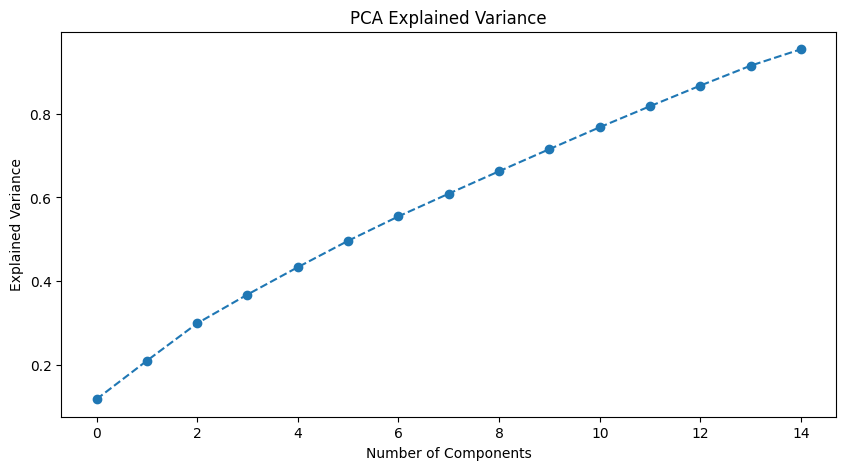

Number of components selected: 15


In [291]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# variance plot
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

# Remaining components
print(f"Number of components selected: {X_pca.shape[1]}")


KMeans Clustering

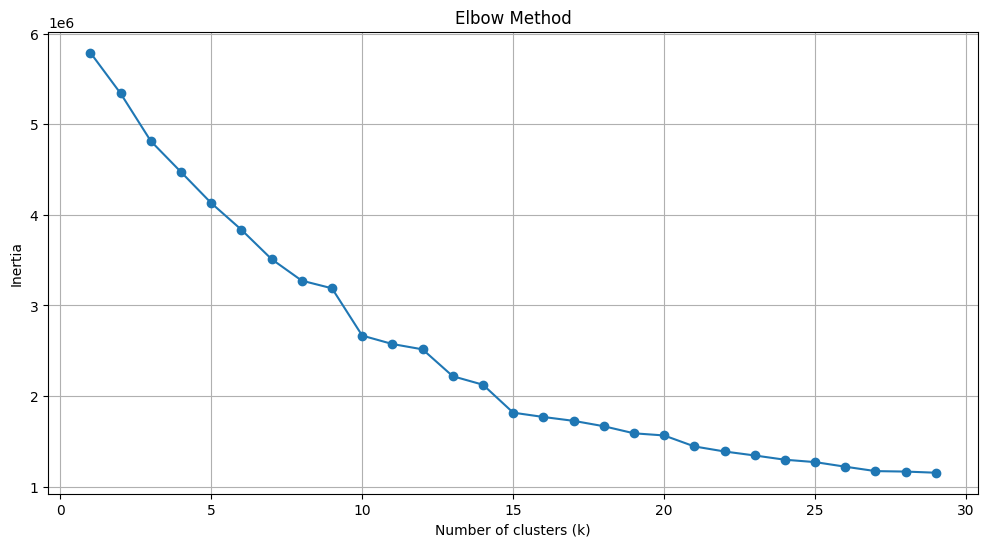

In [292]:
# Using elbow method to identify clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 30):
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(12, 6))
plt.plot(range(1, 30), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid()
plt.show()

In [293]:
# Kmeans clustering
kmeans = KMeans(n_clusters=10, random_state=42,max_iter=1000)
kmeans.fit(X_scaled)


homicide_data["Cluster"] = kmeans.labels_

In [294]:
homicide_data.head()

,Victim Count,Victim Age Group,Date,Time_Diff,Crime_Frequency,State_Crime_Category,Victim Sex_Female,Victim Sex_Male,Perpetrator Sex_Female,Perpetrator Sex_Male,...,Relationship_Stepfamily,Relationship_Stranger,Relationship_Work/Employer,Weapon_Blunt Objects,Weapon_Environmental/Accidental,Weapon_Firearms,Weapon_Other,Weapon_Poisoning,Weapon_Strangulation/Suffocation,Cluster
0,0,5,1980-01-01,0.0,9768,2,True,False,False,True,...,False,False,False,False,False,True,False,False,False,2
1,0,5,1980-01-01,0.0,7086,2,False,True,False,True,...,False,False,False,False,False,True,False,False,False,1
2,0,0,1980-01-01,0.0,12818,0,False,True,False,True,...,False,False,False,False,False,True,False,False,False,2
3,0,5,1980-01-01,0.0,14178,0,False,True,True,False,...,False,False,False,False,False,True,False,False,False,9
4,0,0,1980-01-01,0.0,5711,2,False,True,False,True,...,False,False,False,False,False,True,False,False,False,1


In [295]:
print(homicide_data["Cluster"].value_counts())

Cluster
4    92366
1    64302
0    37323
6    37230
2    34367
3    28759
9    11915
8     5924
5     4037
7     3004
Name: count, dtype: int64


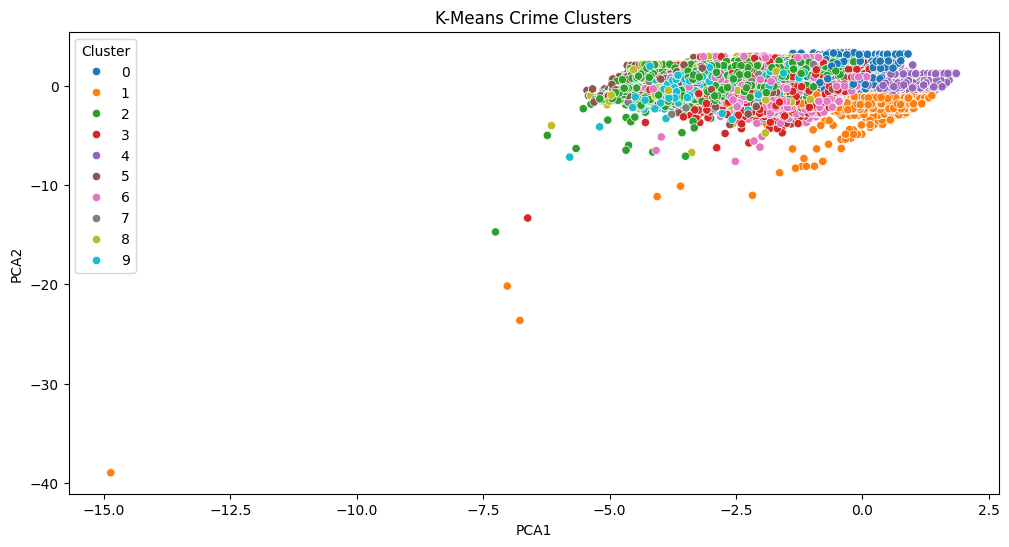

In [296]:
# Visualize with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
homicide_data['PCA1'] = X_pca[:, 0]
homicide_data['PCA2'] = X_pca[:, 1]

# Plot K-Means Clusters
plt.figure(figsize=(12, 6))
sns.scatterplot(data=homicide_data, x='PCA1', y='PCA2', hue='Cluster', palette='tab10')
plt.title('K-Means Crime Clusters')
plt.show()

<ipython-input-297-2828eef811a9>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='tab10')


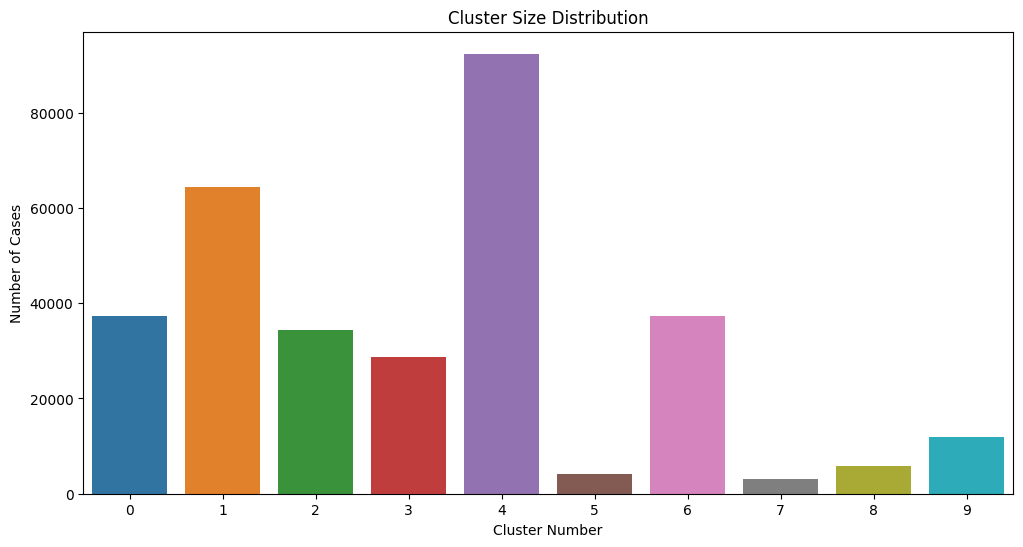

In [297]:
# Count the number of cases per cluster
cluster_counts = homicide_data['Cluster'].value_counts().sort_index()

# Bar chart of cluster sizes
plt.figure(figsize=(12, 6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='tab10')
plt.xlabel('Cluster Number')
plt.ylabel('Number of Cases')
plt.title('Cluster Size Distribution')
plt.show()


In [298]:
# Group the data by clusters and get summary statistics
cluster_summary = homicide_data.groupby('Cluster')[features].describe()
print(cluster_summary)

        Time_Diff                                                   \
            count      mean        std  min  25%  50%  75%     max   
Cluster                                                              
0         37323.0  1.626638   7.624733  0.0  0.0  0.0  0.0   243.0   
1         64302.0  3.495801  18.053841  0.0  0.0  0.0  0.0  2405.0   
2         34367.0  2.645823  12.833027  0.0  0.0  0.0  0.0   943.0   
3         28759.0  2.431135  11.503377  0.0  0.0  0.0  0.0   822.0   
4         92366.0  0.625804   4.322136  0.0  0.0  0.0  0.0    61.0   
5          4037.0  2.176369   9.587354  0.0  0.0  0.0  0.0   153.0   
6         37230.0  2.120064   9.695398  0.0  0.0  0.0  0.0   397.0   
7          3004.0  2.870506  11.755765  0.0  0.0  0.0  0.0   214.0   
8          5924.0  2.509115  11.411261  0.0  0.0  0.0  0.0   334.0   
9         11915.0  2.753084  11.866534  0.0  0.0  0.0  0.0   426.0   

        Crime_Frequency                ... Victim Count        \
                  count 

<ipython-input-299-f9161784bc46>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster', y='Victim Count', data=cluster_avg_victim_count, palette='Set2')


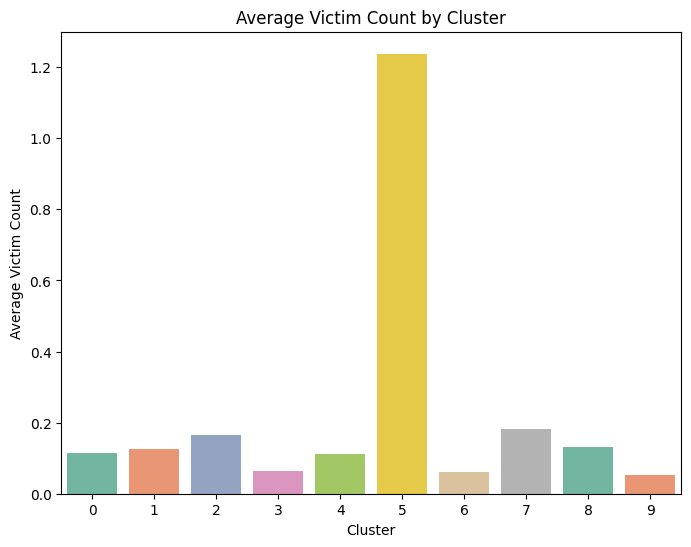

In [299]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the average victim count per cluster
cluster_avg_victim_count = homicide_data.groupby("Cluster")["Victim Count"].mean().reset_index()

# Bar plot to show the average victim count for each cluster
plt.figure(figsize=(8, 6))
sns.barplot(x='Cluster', y='Victim Count', data=cluster_avg_victim_count, palette='Set2')
plt.title('Average Victim Count by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Victim Count')
plt.show()


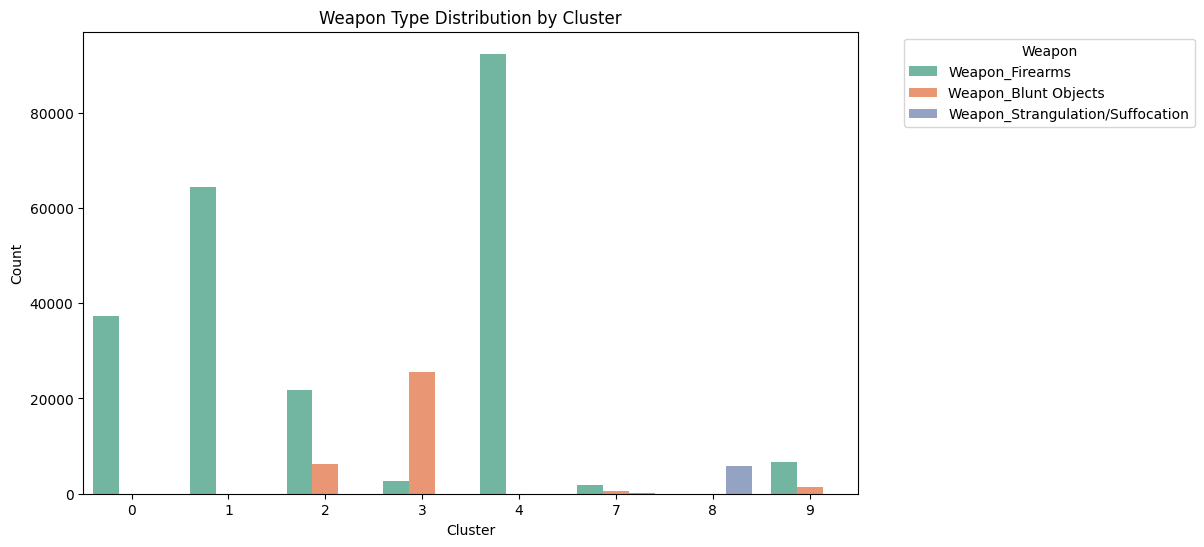

In [300]:
# Count plot to show the frequency of weapon types for each cluster
plt.figure(figsize=(10, 6))
weapon_categories = ['Weapon_Firearms', 'Weapon_Blunt Objects', 'Weapon_Strangulation/Suffocation']
melted_data = pd.melt(homicide_data, id_vars=['Cluster'], value_vars=weapon_categories, var_name='Weapon', value_name='Count')
sns.countplot(x='Cluster', hue='Weapon', data=melted_data[melted_data['Count'] == 1], palette='Set2')


plt.title('Weapon Type Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Weapon', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

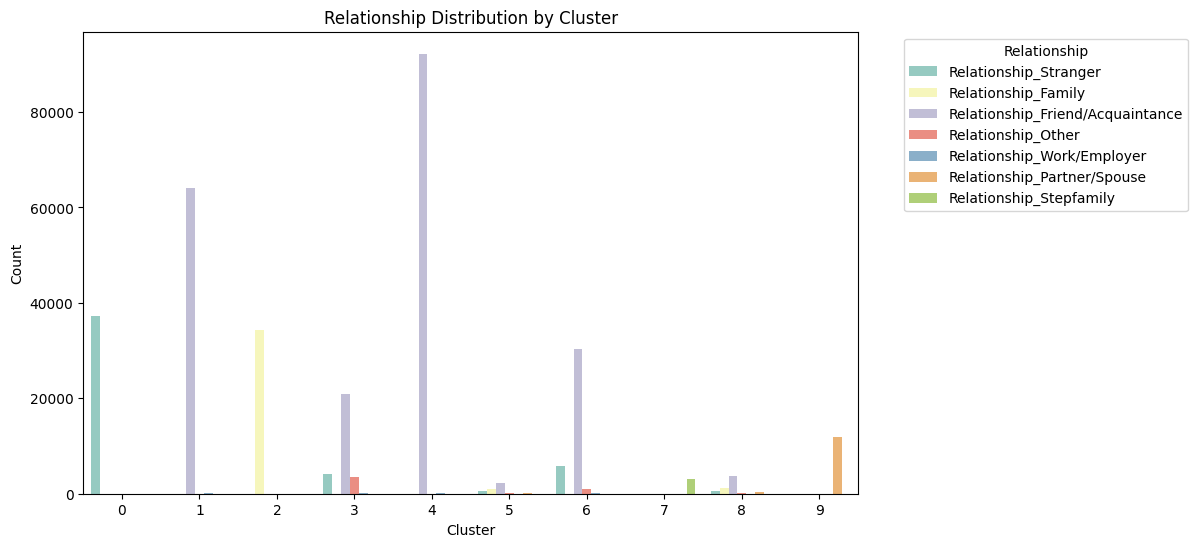

In [301]:
# Count plot to show the frequency of relationship types for each cluster
plt.figure(figsize=(10, 6))
relationship_cols = [col for col in homicide_data.columns if col.startswith('Relationship_')]
melted_data = pd.melt(homicide_data, id_vars=['Cluster'], value_vars=relationship_cols,
                      var_name='Relationship', value_name='Count')
sns.countplot(x='Cluster', hue='Relationship', data=melted_data[melted_data['Count'] == 1], palette='Set3')

plt.title('Relationship Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Relationship', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

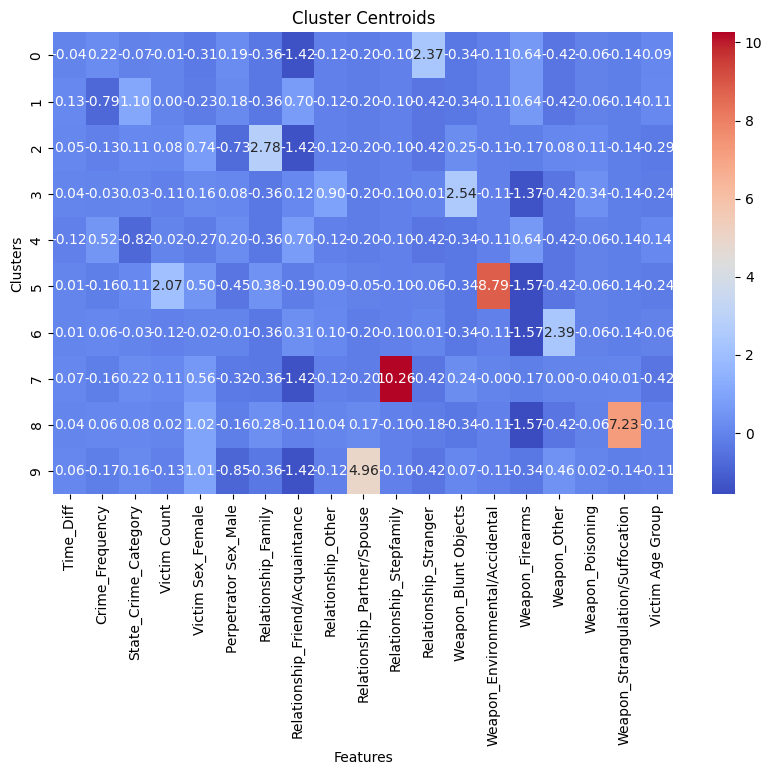

In [302]:
# Plot the cluster centers (centroids) if you're using KMeans
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=features)
centroids['Cluster'] = range(len(centroids))  # Assign a cluster label for the centroids

# Plot the centroids
plt.figure(figsize=(10, 6))
sns.heatmap(centroids.drop('Cluster', axis=1), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Cluster Centroids')
plt.xlabel('Features')
plt.ylabel('Clusters')
plt.show()


In [303]:
# Count crimes per cluster
crime_freq = homicide_data.groupby("Cluster")["Date"].count().reset_index()
crime_freq.columns = ["Cluster", "Crime_Frequency"]

# Sort clusters by frequency (higher = more potential for serial crimes)
crime_freq = crime_freq.sort_values(by="Crime_Frequency", ascending=False)

print(crime_freq.head(10))


   Cluster  Crime_Frequency
4        4            92366
1        1            64302
0        0            37323
6        6            37230
2        2            34367
3        3            28759
9        9            11915
8        8             5924
5        5             4037
7        7             3004


In [304]:
def label_cluster(cluster_id):
    if cluster_id in [1,4,5]:
        return 'Potentially Serial'
    else:
        return 'Non-Serial'

homicide_data['Cluster_Label'] = homicide_data['Cluster'].apply(label_cluster)
print(homicide_data[['Cluster', 'Cluster_Label']].head())


   Cluster       Cluster_Label
0        2          Non-Serial
1        1  Potentially Serial
2        2          Non-Serial
3        9          Non-Serial
4        1  Potentially Serial


In [305]:
homicide_data.head()

,Victim Count,Victim Age Group,Date,Time_Diff,Crime_Frequency,State_Crime_Category,Victim Sex_Female,Victim Sex_Male,Perpetrator Sex_Female,Perpetrator Sex_Male,...,Weapon_Blunt Objects,Weapon_Environmental/Accidental,Weapon_Firearms,Weapon_Other,Weapon_Poisoning,Weapon_Strangulation/Suffocation,Cluster,PCA1,PCA2,Cluster_Label
0,0,5,1980-01-01,0.0,9768,2,True,False,False,True,...,False,False,True,False,False,False,2,-1.496201,0.009638,Non-Serial
1,0,5,1980-01-01,0.0,7086,2,False,True,False,True,...,False,False,True,False,False,False,1,1.312650,-1.221752,Potentially Serial
2,0,0,1980-01-01,0.0,12818,0,False,True,False,True,...,False,False,True,False,False,False,2,-0.859772,1.027600,Non-Serial
3,0,5,1980-01-01,0.0,14178,0,False,True,True,False,...,False,False,True,False,False,False,9,-1.492900,1.079762,Non-Serial
4,0,0,1980-01-01,0.0,5711,2,False,True,False,True,...,False,False,True,False,False,False,1,0.894353,-1.305268,Potentially Serial


In [306]:
homicide_data = homicide_data.drop(columns=["Cluster","PCA1","PCA2"])

In [307]:
homicide_data.head()

,Victim Count,Victim Age Group,Date,Time_Diff,Crime_Frequency,State_Crime_Category,Victim Sex_Female,Victim Sex_Male,Perpetrator Sex_Female,Perpetrator Sex_Male,...,Relationship_Stepfamily,Relationship_Stranger,Relationship_Work/Employer,Weapon_Blunt Objects,Weapon_Environmental/Accidental,Weapon_Firearms,Weapon_Other,Weapon_Poisoning,Weapon_Strangulation/Suffocation,Cluster_Label
0,0,5,1980-01-01,0.0,9768,2,True,False,False,True,...,False,False,False,False,False,True,False,False,False,Non-Serial
1,0,5,1980-01-01,0.0,7086,2,False,True,False,True,...,False,False,False,False,False,True,False,False,False,Potentially Serial
2,0,0,1980-01-01,0.0,12818,0,False,True,False,True,...,False,False,False,False,False,True,False,False,False,Non-Serial
3,0,5,1980-01-01,0.0,14178,0,False,True,True,False,...,False,False,False,False,False,True,False,False,False,Non-Serial
4,0,0,1980-01-01,0.0,5711,2,False,True,False,True,...,False,False,False,False,False,True,False,False,False,Potentially Serial


In [308]:
from google.colab import drive
drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/DSGP/homicide_serial_labeled.csv"
homicide_data.to_csv(save_path, index=False)
print(f"Dataset saved to {save_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset saved to /content/drive/MyDrive/DSGP/homicide_serial_labeled.csv
